# Superstore Sales Analysis
### Exploratory Data Analysis using Python

Author: Divyajyoti Tripathy

## 1. Problem Statement

The goal of this project is to analyze retail sales data to identify:
- Top customers
- Best performing categories
- Sales trends over time

## 2. Data Overview

The dataset contains information about orders, customers, products, sales, and shipping details.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Data Loading

In [2]:
df = pd.read_csv("../data/samplesuperstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           10194 non-null  float64
 1

## 4. Data Cleaning

In [5]:
df =df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
df["Order Date"] = pd.DatetimeIndex(df["Order Date"])
df['Ship Date'] = pd.DatetimeIndex(df["Ship Date"])

In [7]:
def check(df):
    l = []
    for col in df.columns:
        l.append([
            col,
            df[col].dtypes,
            df[col].nunique(),
            df[col].isnull().sum()
        ])
    return pd.DataFrame(l, columns=['column','dtypes','nunique','sum_null'])

check(df)

,column,dtypes,nunique,sum_null
0,Row ID,int64,10194,0
1,Order ID,str,5111,0
2,Order Date,datetime64[us],1242,0
3,Ship Date,datetime64[us],1338,0
4,Ship Mode,str,4,0
5,Customer ID,str,804,0
6,Customer Name,str,800,0
7,Segment,str,3,0
8,Country/Region,str,2,0
9,City,str,542,0


In [8]:
df[df["Postal Code"].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [9]:
# Postal code for Burlington is 5401
df["Postal Code"]=df ["Postal Code"].fillna(5401.0)

<Axes: >

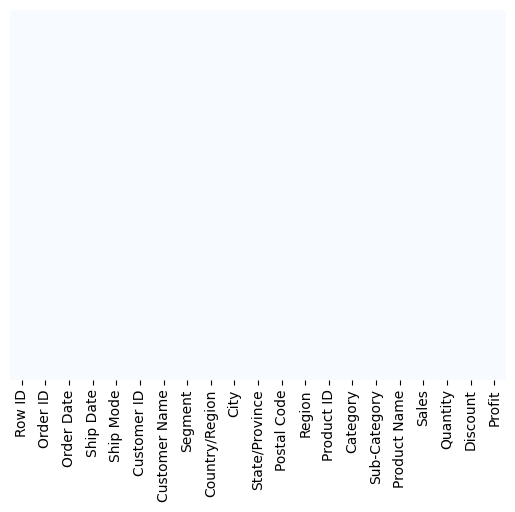

In [10]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap="Blues")

## 5. Feature Engineering

In [11]:
df['Year'] = pd.DatetimeIndex(df['Order Date']).year
df['Month'] = pd.DatetimeIndex(df['Order Date']).month
df['Day'] = pd.DatetimeIndex(df['Order Date']).day

### Insight

- Sales fluctuate across months, indicating seasonality.
- Certain months show peak demand.
- Business can align promotions with high-demand periods.

In [12]:
df['Day of Week'] = df['Order Date'].dt.strftime('%A')

## 6. Exploratory Data Analysis

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,10194.0,5097.5,1.0,2549.25,5097.5,7645.75,10194.0,2942.898656
Order Date,10194,2025-04-29 11:48:25.002943,2023-01-03 00:00:00,2024-05-14 00:00:00,2025-06-25 00:00:00,2026-05-14 00:00:00,2026-12-30 00:00:00,NaN
Ship Date,10194,2025-05-03 10:52:45.626839,2023-01-07 00:00:00,2024-05-19 00:00:00,2025-06-28 00:00:00,2026-05-18 00:00:00,2027-01-05 00:00:00,NaN
Sales,10194.0,228.225854,0.444,17.22,53.91,209.5,22638.48,619.906839
Quantity,10194.0,3.791838,1.0,2.0,3.0,5.0,14.0,2.228317
Discount,10194.0,0.155385,0.0,0.0,0.2,0.2,0.8,0.206249
Profit,10194.0,28.673417,-6599.978,1.7608,8.69,29.297925,8399.976,232.465115
Year,10194.0,2024.720129,2023.0,2024.0,2025.0,2026.0,2026.0,1.125611
Month,10194.0,7.81185,1.0,5.0,9.0,11.0,12.0,3.295915
Day,10194.0,15.445066,1.0,8.0,15.0,23.0,31.0,8.729661


array([[<Axes: title={'center': 'Order Date'}>,
        <Axes: title={'center': 'Ship Date'}>],
       [<Axes: title={'center': 'Sales'}>,
        <Axes: title={'center': 'Year'}>],
       [<Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'Day'}>]], dtype=object)

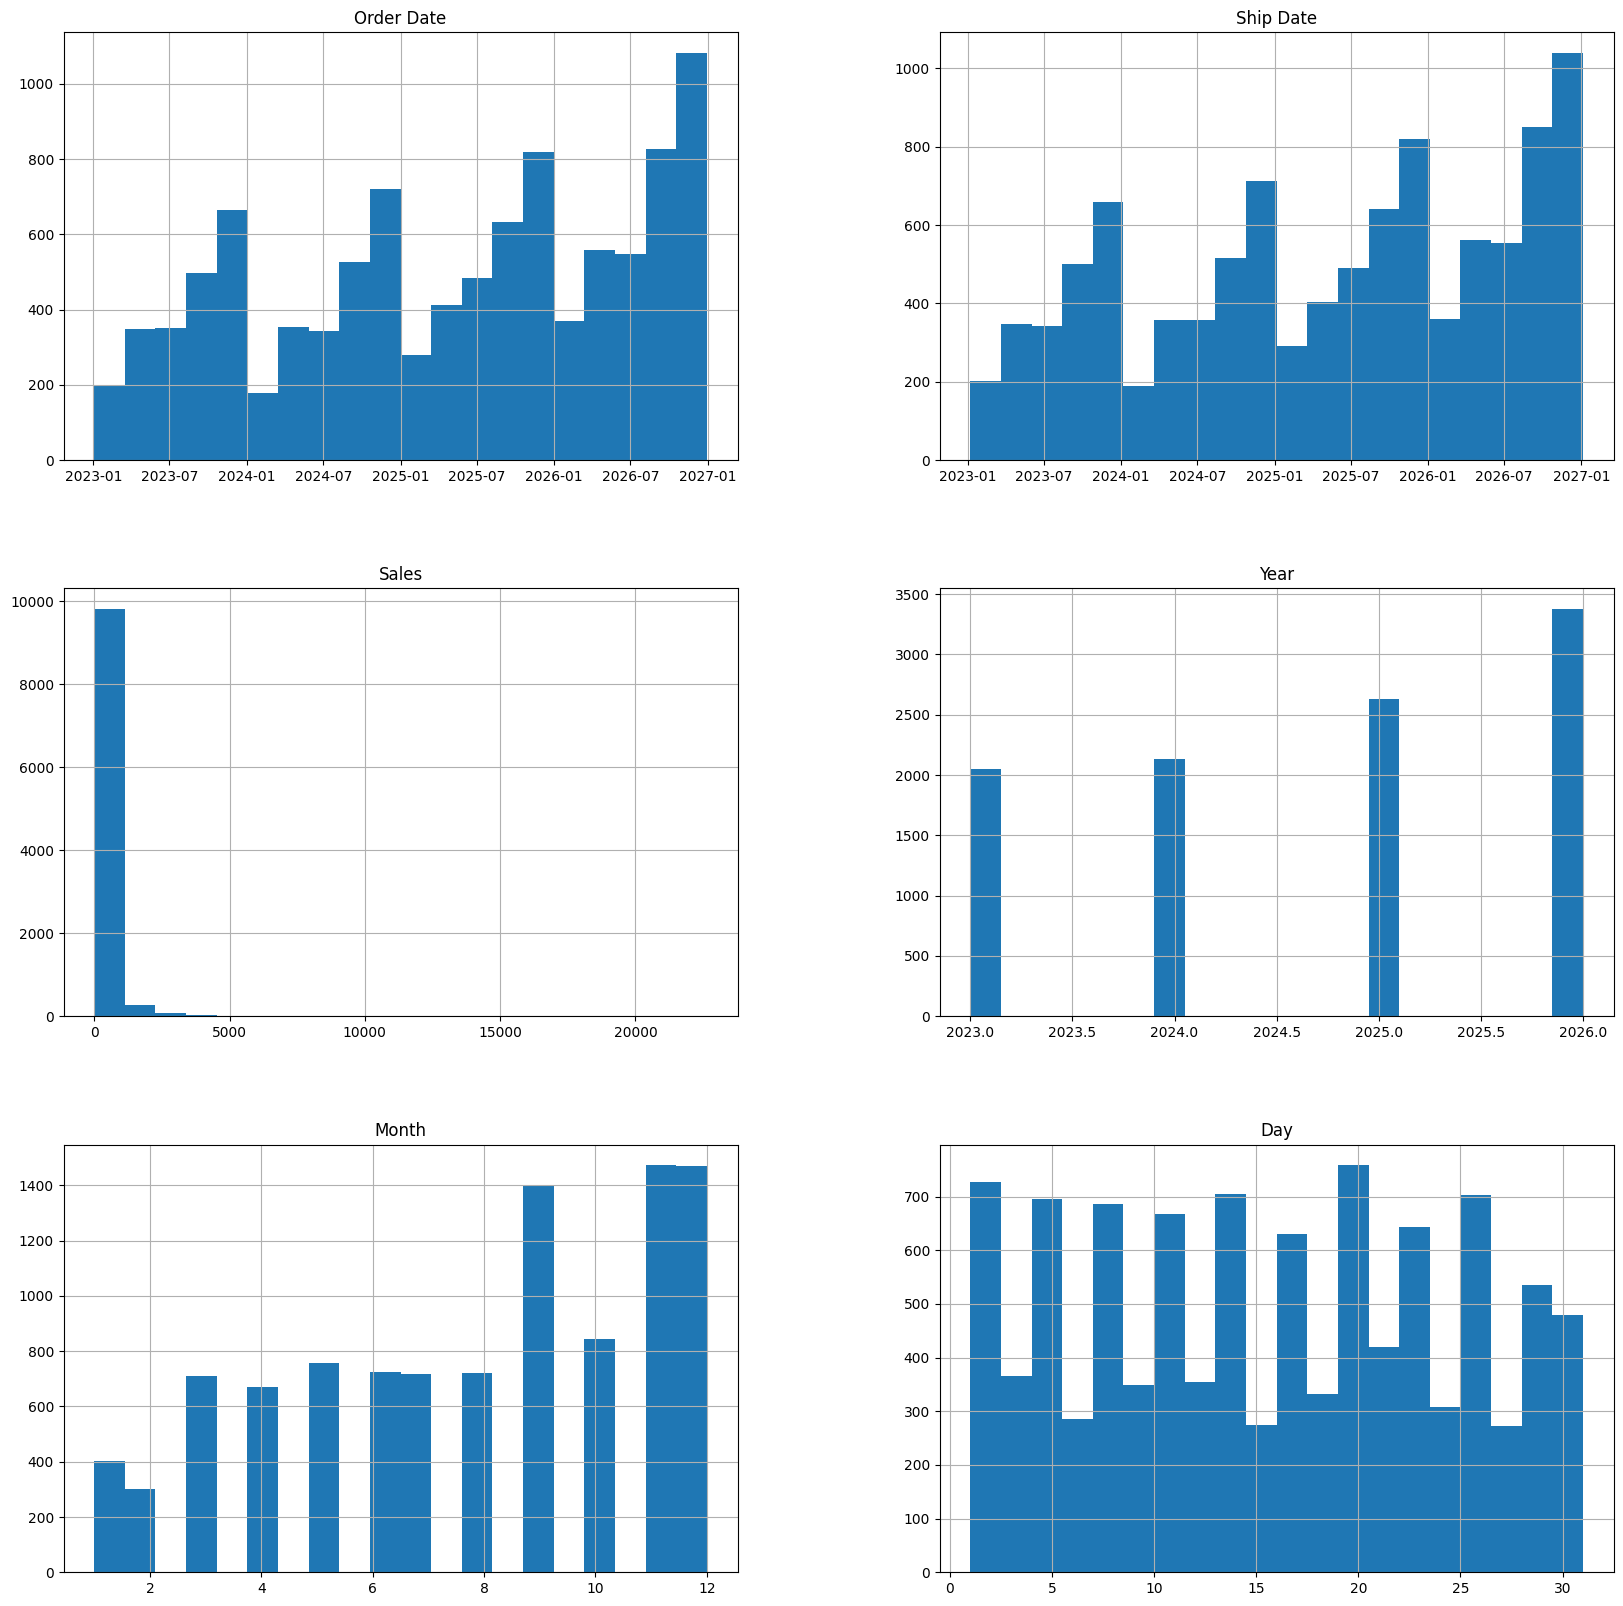

In [14]:
df[['Order Date' , 'Ship Date' , 'Sales' , 'Year', 'Month', 'Day']].hist(bins=20 ,figsize = (20,20))

## 6.1. Category Performance

In [27]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

## 6.2. Region Performance

In [28]:
df.groupby('Region')['Sales'].sum()

Region
Central    503170.6728
East       691828.1680
South      391721.9050
West       739813.6085
Name: Sales, dtype: float64

## 7. Sales by Category

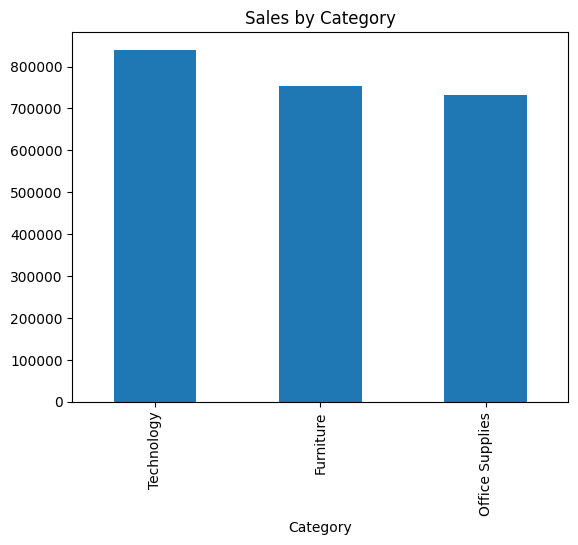

In [15]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

### Insight

- Technology category generates the highest sales.
- Furniture and Office Supplies show moderate performance.
- Business should focus inventory and marketing on high-performing categories.

In [16]:
best_customer = df.groupby("Customer Name")["Sales"].sum()
best_customer = best_customer.sort_values(ascending=False).head(10).reset_index()


In [21]:
import pandas as pd

# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Month column
df['Month'] = df['Order Date'].dt.to_period('M')

# Aggregate sales per month
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

# Convert Month to timestamp for plotting
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

# Sort values (important)
monthly_sales = monthly_sales.sort_values('Month')

(array([19358., 19539., 19723., 19905., 20089., 20270., 20454., 20635.,
        20819.]),
 [Text(19358.0, 0, '2023-01'),
  Text(19539.0, 0, '2023-07'),
  Text(19723.0, 0, '2024-01'),
  Text(19905.0, 0, '2024-07'),
  Text(20089.0, 0, '2025-01'),
  Text(20270.0, 0, '2025-07'),
  Text(20454.0, 0, '2026-01'),
  Text(20635.0, 0, '2026-07'),
  Text(20819.0, 0, '2027-01')])

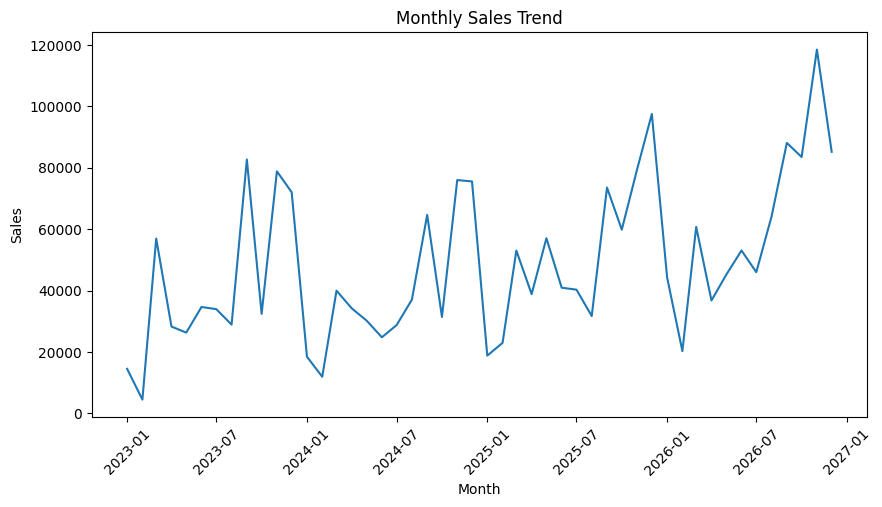

In [ ]:
# creating the line plot
plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Sales', data=monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

### Insight
Sales show an overall upward trend with noticeable fluctuations across months. Significant spikes appear in certain periods, indicating seasonal or campaign-driven demand.

### Why it matters
The variability suggests demand is not uniform and may depend on external factors such as promotions or seasonal buying behavior.

### Business Action
- Increase inventory before peak months
- Align marketing campaigns with high-growth periods
- Investigate causes behind sharp drops to stabilize revenue

(array([19358., 19539., 19723., 19905., 20089., 20270., 20454., 20635.,
        20819.]),
 [Text(19358.0, 0, '2023-01'),
  Text(19539.0, 0, '2023-07'),
  Text(19723.0, 0, '2024-01'),
  Text(19905.0, 0, '2024-07'),
  Text(20089.0, 0, '2025-01'),
  Text(20270.0, 0, '2025-07'),
  Text(20454.0, 0, '2026-01'),
  Text(20635.0, 0, '2026-07'),
  Text(20819.0, 0, '2027-01')])

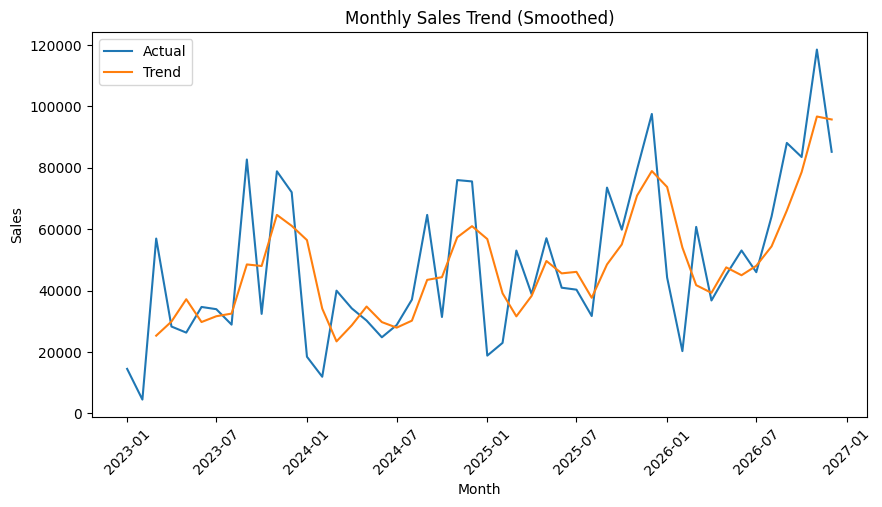

In [26]:
monthly_sales['Rolling Avg'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Sales', data=monthly_sales, label='Actual')
sns.lineplot(x='Month', y='Rolling Avg', data=monthly_sales, label='Trend')

plt.title("Monthly Sales Trend (Smoothed)")
plt.xticks(rotation=45)

In [24]:
# Top 3 months
monthly_sales.sort_values('Sales', ascending=False).head(3)

# Bottom 3 months
monthly_sales.sort_values('Sales').head(3)

,Month,Sales
1,2023-02-01,4519.892
13,2024-02-01,11951.411
0,2023-01-01,14518.055


### Insight
Top-performing months are concentrated in late-year periods, while early-year months show relatively lower sales.

### Business Action
Focus promotional budgets on historically strong months to maximize ROI.

In [23]:
best_category = df.pivot_table(values = "Sales" , index = "Category" , aggfunc = "sum")
best_category = best_category.sort_values(by=['Sales'], ascending=False).head()
best_category.reset_index(inplace=True)
best_category['Sales']=best_category['Sales'].round(2)
best_category

,Category,Sales
0,Technology,839893.28
1,Furniture,754747.76
2,Office Supplies,731893.31


## 8. Key Insights

- Technology category generates the highest overall sales.
- A small group of customers contribute disproportionately to total revenue.
- Sales are concentrated in specific product categories, indicating potential dependency risks.

## 9. Final Conclusions

### 1. Sales Trend Over Time
Sales exhibit an overall upward trajectory with noticeable fluctuations across months. Peak periods suggest strong seasonal demand, likely influenced by promotional cycles or year-end purchasing behavior.

### 2. Category Performance
Certain product categories contribute disproportionately to revenue, indicating a need to prioritize high-performing segments while optimizing underperforming ones.

### 3. Regional Insights
Sales distribution varies across regions, highlighting opportunities for targeted expansion and region-specific marketing strategies.

### 4. Demand Variability
The presence of sharp spikes and drops suggests inconsistent demand patterns, requiring better forecasting and inventory planning.

---

## Business Recommendations

- Align inventory planning with high-demand months to avoid stockouts
- Focus marketing efforts on top-performing categories to maximize ROI
- Optimize pricing or discount strategies for low-performing segments
- Develop region-specific strategies to capture untapped market potential
- Implement demand forecasting models to reduce volatility in sales